In [269]:
# =====================================================================
# GOTFlow (GeomLoss-based) — UPDATED core with negative modelling for Step C
#
# Change in Step C:
# -----------------
# ✅ Adds contrastive "InfoNCE-on-energies" transition fitting using RANDOM NEGATIVE EDGES
#    - For each source S and each positive outgoing edge (S->T+),
#      sample M negatives T- with (S->T-) not in E (this naturally includes inverse edges).
#    - Resample negatives every epoch (or every step) for diversity.
#
# What stays the same:
# --------------------
# ✅ Edge-weighted OT training (Step B)
# ✅ Whitening, drift, speed, confidence, test-speed
# ✅ p(T|S) scoring from full-edge energies after fit
#
# Dependencies: numpy, torch, geomloss, matplotlib, sklearn
# =====================================================================

from __future__ import annotations
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from geomloss import SamplesLoss
from typing import Optional, Iterable, Dict, Tuple, List, Any

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.cluster import KMeans


# ----------------------------- helpers -----------------------------

def _is_scalar(x) -> bool:
    try:
        return np.isscalar(x)
    except Exception:
        return isinstance(x, (int, float))

def _expand_param(param, n_edges: int, name: str) -> List[float]:
    if _is_scalar(param):
        return [float(param)] * n_edges
    arr = list(param)
    if len(arr) != n_edges:
        raise ValueError(f"{name} must be scalar or length {n_edges}. Got {len(arr)}.")
    return [float(v) for v in arr]

def _safe_normalize_weights(w: np.ndarray) -> np.ndarray:
    w = np.asarray(w, float).reshape(-1)
    s = float(w.sum())
    return w / (s if s > 0 else 1.0)

def _pairwise_sq_dists(X: np.ndarray, Y: np.ndarray) -> np.ndarray:
    x2 = np.sum(X * X, axis=1, keepdims=True)
    y2 = np.sum(Y * Y, axis=1, keepdims=True).T
    D2 = x2 + y2 - 2.0 * (X @ Y.T)
    return np.maximum(D2, 0.0)

def _whiten_fit(Z: np.ndarray, lambda_w: float = 1e-3) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Return (mu, W, Sigma) where W=(Sigma+lambda I)^(-1/2) via eigen-decomp.
    """
    Z = np.asarray(Z, float)
    mu = Z.mean(axis=0, keepdims=True)
    Xc = Z - mu
    Sigma = (Xc.T @ Xc) / max(1, Z.shape[0])
    d = Sigma.shape[0]
    evals, evecs = np.linalg.eigh(Sigma + lambda_w * np.eye(d))
    evals = np.maximum(evals, 1e-12)
    inv_sqrt = evecs @ np.diag(1.0 / np.sqrt(evals)) @ evecs.T
    return mu.squeeze(0), inv_sqrt, Sigma

def _whiten_apply(Z: np.ndarray, mu: np.ndarray, W: np.ndarray) -> np.ndarray:
    return (Z - mu.reshape(1, -1)) @ W.T


# ---------------------- generalized sinkhorn (u,v) ----------------------

def generalized_sinkhorn_uv(
    X_src: np.ndarray,
    X_tgt: np.ndarray,
    a: np.ndarray,
    b: np.ndarray,
    eps: float,
    alpha: float,
    *,
    max_iter: int = 200,
    tol: float = 1e-6,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute u,v for (approx.) unbalanced entropic OT with exponent alpha, using K=exp(-C/eps).

    Returns
    -------
    u : (n,)
    v : (m,)
    K : (n,m)
    """
    X_src = np.asarray(X_src, float)
    X_tgt = np.asarray(X_tgt, float)
    a = np.maximum(np.asarray(a, float).reshape(-1), 1e-16)
    b = np.maximum(np.asarray(b, float).reshape(-1), 1e-16)

    C = _pairwise_sq_dists(X_src, X_tgt)
    eps = float(max(eps, 1e-12))
    K = np.exp(-C / eps)

    u = np.ones(X_src.shape[0], dtype=np.float64)
    v = np.ones(X_tgt.shape[0], dtype=np.float64)

    KT = K.T
    for _ in range(int(max_iter)):
        Kv = K @ v
        Kv = np.maximum(Kv, 1e-300)
        u_new = (a / Kv) ** alpha

        KTu = KT @ u_new
        KTu = np.maximum(KTu, 1e-300)
        v_new = (b / KTu) ** alpha

        du = np.max(np.abs(np.log(u_new + 1e-300) - np.log(u + 1e-300)))
        dv = np.max(np.abs(np.log(v_new + 1e-300) - np.log(v + 1e-300)))
        u, v = u_new, v_new
        if max(du, dv) < tol:
            break

    return u, v, K

def uv_to_plan(u: np.ndarray, v: np.ndarray, K: np.ndarray) -> np.ndarray:
    return (u[:, None] * K) * v[None, :]


# =====================================================================
# GOTFlow
# =====================================================================

class GOTFlow:
    """
    GOTFlow core:
      1) z = phi_theta(x) (Identity by default)
      2) whiten: \tilde z = W (z - mu)
      3) energies per edge via GeomLoss SamplesLoss
      4) drift per sample:
         - grad: -∇_{tilde z_i} E_ST
         - barycentric: ybar - x using P=u*K*v
      5) aggregate across outgoing edges with edge weights w_ST
      6) speed = ||drift|| + confidence (mass, entropy) (plan-based)
      7) test-time speed via stored (target embeddings, v scaling) per edge
      8) transition scoring p(T|S) ∝ exp(-β E_ST) after fit

    UPDATED Step C:
      - contrastive transition fitting via InfoNCE on energies using random negative edges.
    """

    def __init__(
        self,
        *,
        blur: float | List[float] | np.ndarray = 0.05,
        scaling: float | List[float] | np.ndarray = 0.9,
        reach: float | List[float] | np.ndarray = 0.5,
        # representation
        phi: Optional[nn.Module] = None,  # if None -> Identity
        # whitening
        lambda_w: float = 1e-3,
        # energy type
        debias: bool = True,              # Sinkhorn divergence (debias) vs raw
        # device
        device: Optional[str] = None,
        dtype: torch.dtype = torch.float32,
    ):
        self.blur = blur
        self.scaling = scaling
        self.reach = reach
        self.debias = debias

        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.dtype = dtype

        self.phi = phi if phi is not None else nn.Identity()
        self.phi.to(self.device)

        self.lambda_w = float(lambda_w)

        # learned / fitted state
        self.X: Optional[np.ndarray] = None
        self.bin_ids: Optional[np.ndarray] = None
        self.edges_: Optional[List[Tuple[int, int]]] = None
        self.edge_wts_: Optional[List[float]] = None

        # whitening
        self.mu_z_: Optional[np.ndarray] = None
        self.Wwhiten_: Optional[np.ndarray] = None

        # embeddings
        self.z_: Optional[np.ndarray] = None
        self.zw_: Optional[np.ndarray] = None

        # drifts
        self.Vw_: Optional[np.ndarray] = None
        self.edge_drift_: Dict[Tuple[int,int], np.ndarray] = {}

        # per-edge cache for test-time + confidence
        self.edge_cache_: Dict[Tuple[int, int], dict] = {}
        self.transport_plan_: Dict[Tuple[int,int], np.ndarray] = {}

        # per-edge energies + logs
        self.edge_energy_: Dict[Tuple[int,int], float] = {}
        self.edge_log_: List[dict] = []

        # per-source transition scores
        self.p_edge_: Dict[int, Dict[int, float]] = {}

        self.loss_log_ = []

    # ----------------------- convenience: make an MLP -----------------------

    @staticmethod
    def make_mlp(d_in: int, d_out: int = 8, hidden: int = 64, depth: int = 2, batch_norm: bool = False, dropout=0.0
                 ) -> nn.Module:
        layers: List[nn.Module] = []
        din = d_in
        for _ in range(max(1, depth)):
            layers += [nn.Linear(din, hidden)]
            layers += [nn.BatchNorm1d(hidden)] if batch_norm else []
            layers += [nn.Dropout(dropout)] if dropout > 0 else []
            layers += [nn.ReLU()]
            din = hidden
        layers += [nn.Linear(din, d_out)]
        
        return nn.Sequential(*layers)
    # ----------------------------- binning -----------------------------

    @staticmethod
    def quantile_bin(t: np.ndarray, K: int, right: bool = False):
        t = np.asarray(t, dtype=float).reshape(-1)
        assert K >= 1
        qs = np.quantile(t, np.linspace(0.0, 1.0, K + 1))
        bin_ids = np.clip(np.digitize(t, qs[1:-1], right=right), 0, K - 1)
        return bin_ids.astype(int), qs

    # -------------------------- embedding + whitening --------------------------

    def _embed_torch(self, X: np.ndarray, requires_grad: bool = False) -> torch.Tensor:
        Xt = torch.tensor(X, dtype=self.dtype, device=self.device, requires_grad=requires_grad)
        return self.phi(Xt)

    def _embed_np(self, X: np.ndarray, batch: int = 20000) -> np.ndarray:
        self.phi.eval()
        out = []
        with torch.no_grad():
            for i in range(0, X.shape[0], batch):
                z = self._embed_torch(X[i:i+batch], requires_grad=False)
                out.append(z.detach().cpu().numpy())
        return np.vstack(out)

    def _fit_whitening(self, Z: np.ndarray):
        mu, W, _ = _whiten_fit(Z, lambda_w=self.lambda_w)
        self.mu_z_ = mu.astype(np.float32, copy=False)
        self.Wwhiten_ = W.astype(np.float32, copy=False)

    def _whiten_np(self, Z: np.ndarray) -> np.ndarray:
        assert self.mu_z_ is not None and self.Wwhiten_ is not None
        return _whiten_apply(Z, self.mu_z_, self.Wwhiten_).astype(np.float32, copy=False)

    def _whiten_torch(self, z: torch.Tensor) -> torch.Tensor:
        assert self.mu_z_ is not None and self.Wwhiten_ is not None
        mu = torch.tensor(self.mu_z_, dtype=z.dtype, device=z.device).view(1, -1)
        W = torch.tensor(self.Wwhiten_, dtype=z.dtype, device=z.device)
        return (z - mu) @ W.T

    # -------------------------- geomloss loss cache --------------------------

    def _get_loss(self, blur: float, scaling: float, reach: float) -> SamplesLoss:
        try:
            return SamplesLoss(
                "sinkhorn", p=2,
                blur=float(blur), scaling=float(scaling), reach=float(reach),
                debias=bool(self.debias),
            )
        except TypeError:
            return SamplesLoss("sinkhorn", p=2, blur=float(blur), scaling=float(scaling), reach=float(reach))

    @staticmethod
    def _loss_with_weights(loss_fn: SamplesLoss, x: torch.Tensor, y: torch.Tensor,
                          a: Optional[torch.Tensor], b: Optional[torch.Tensor]) -> torch.Tensor:
        try:
            if a is not None and b is not None:
                return loss_fn(x, y, weights_x=a.reshape(-1), weights_y=b.reshape(-1))
        except TypeError:
            pass
        try:
            if a is not None and b is not None:
                return loss_fn(x, y, a=a.reshape(-1), b=b.reshape(-1))
        except TypeError:
            pass
        return loss_fn(x, y)

    # -------------------------- transition scoring utilities --------------------------

    @staticmethod
    def _softmax_dict(energies: Dict[int, float], beta: float) -> Dict[int, float]:
        Ts = list(energies.keys())
        if not Ts:
            return {}
        vals = np.array([energies[t] for t in Ts], float)
        vals = vals - np.min(vals)
        logits = -float(beta) * vals
        logits = logits - np.max(logits)
        p = np.exp(logits)
        p = p / (p.sum() + 1e-12)
        return {int(Ts[i]): float(p[i]) for i in range(len(Ts))}

    # =====================================================================
    # FIT (UPDATED: Step C InfoNCE negative sampling)
    # =====================================================================

    def fit(
        self,
        X: np.ndarray,
        bin_ids: np.ndarray,
        *,
        edges: Optional[Iterable[Tuple[int, int]]] = None,
        edge_weights: Optional[Dict[Tuple[int, int], float] | List[float] | np.ndarray] = None,
        sample_weights: Optional[np.ndarray] = None,
        normalize_weights: bool = False,

        # learning modes
        learn_phi: bool = False,                  # Step B/C
        transition_fit: bool = False,             # Step C
        transition_fit_mode: str = "nce",         # {"nce","kl"}  (KL kept only for compatibility)
        beta: float = 6.0,                        # temperature for edge softmax (also used in NCE logits)
        gamma: float = 1.0,                       # weight for transition fitting loss

        # Step C (NCE) negative sampling
        n_negatives: int = 10,
        resample_negatives_each_epoch: bool = True,
        neg_pool_mode: str = "all",               # {"all","within_window"}
        neg_window: int = 3,                      # used if neg_pool_mode="within_window" (bins around S)
        forbid_self_loops: bool = True,

        # optimiser
        lr: float = 1e-3,
        weight_decay: float = 0.0,
        epochs: int = 200,

        # subsampling during learning
        max_src_per_edge: int = 4000,
        max_tgt_per_edge: int = 4000,
        rng_seed: int = 0,

        # whitening updates during learning
        whiten_update_every: int = 5,
        whiten_max_points: int = 50000,

        # drift computation
        drift_mode: str = "barycentric",          # {"grad","barycentric"}
        sinkhorn_max_iter: int = 200,
        sinkhorn_tol: float = 1e-6,

        # aggregation
        aggregate: str = "weighted_mean",         # {"weighted_mean","sum"}
        verbose: bool = True,
    ):
        X = np.asarray(X, float)
        bin_ids = np.asarray(bin_ids, int).reshape(-1)
        assert X.ndim == 2 and bin_ids.shape[0] == X.shape[0]

        self.X = X
        self.bin_ids = bin_ids

        uniq = np.unique(bin_ids)
        uniq_sorted = np.sort(uniq)
        bin_to_idx = {int(b): np.where(bin_ids == b)[0] for b in uniq_sorted}

        # edges
        if edges is None:
            edges_list = [(int(uniq_sorted[i]), int(uniq_sorted[i + 1])) for i in range(len(uniq_sorted) - 1)]
        else:
            edges_list = [(int(a), int(b)) for (a, b) in list(edges)]
        self.edges_ = edges_list
        L = len(edges_list)
        if L == 0:
            raise ValueError("No edges to fit.")

        # per-edge blur/scaling/reach
        blur_list = _expand_param(self.blur, L, "blur")
        scaling_list = _expand_param(self.scaling, L, "scaling")
        reach_list = _expand_param(self.reach, L, "reach")

        # edge weights
        if edge_weights is None:
            w_list = [1.0] * L
        elif isinstance(edge_weights, dict):
            w_list = [float(edge_weights.get((S, T), 1.0)) for (S, T) in edges_list]
        else:
            w_list = list(np.asarray(edge_weights, float).reshape(-1))
            if len(w_list) != L:
                raise ValueError("edge_weights must be dict or length == len(edges).")
        self.edge_wts_ = w_list

        # sample weights
        sw = None
        if sample_weights is not None:
            sw = np.asarray(sample_weights, float).reshape(-1)
            if sw.shape[0] != X.shape[0]:
                raise ValueError("sample_weights must be length N.")

        rng = np.random.default_rng(rng_seed)

        # initialise whitening from current phi
        Z0 = self._embed_np(X, batch=20000)
        self._fit_whitening(Z0)
        self.z_ = Z0.astype(np.float32, copy=False)
        self.zw_ = self._whiten_np(Z0)

        # outgoing targets per S + set of existing edges for fast membership
        outgoing_by_S: Dict[int, List[int]] = {}
        for (S, T) in edges_list:
            outgoing_by_S.setdefault(int(S), []).append(int(T))
        for S in list(outgoing_by_S.keys()):
            outgoing_by_S[S] = sorted(set(outgoing_by_S[S]))
        edge_set = set((int(S), int(T)) for (S, T) in edges_list)

        # negative pool per S (precomputed candidates)
        all_states = list(map(int, uniq_sorted.tolist()))

        def build_neg_pool_for_S(S: int) -> List[int]:
            posTs = set(outgoing_by_S.get(int(S), []))
            if neg_pool_mode == "within_window":
                # window in the ORDERED bin index space, not value space
                # map S to its position
                s_pos = int(np.where(uniq_sorted == int(S))[0][0])
                lo = max(0, s_pos - int(neg_window))
                hi = min(len(all_states) - 1, s_pos + int(neg_window))
                candidates = [int(uniq_sorted[k]) for k in range(lo, hi + 1)]
            else:
                candidates = all_states

            out = []
            for T in candidates:
                if forbid_self_loops and int(T) == int(S):
                    continue
                if int(T) in posTs:
                    continue
                # negative means NOT in edge list for this S
                if (int(S), int(T)) in edge_set:
                    continue
                out.append(int(T))
            return out

        neg_pool_by_S: Dict[int, List[int]] = {int(S): build_neg_pool_for_S(int(S)) for S in outgoing_by_S.keys()}

        def sample_neg_targets(S: int, k: int) -> List[int]:
            pool = neg_pool_by_S.get(int(S), [])
            if not pool:
                return []
            k = int(min(k, len(pool)))
            return list(rng.choice(pool, size=k, replace=False))

        # cached geomloss objects for per-edge params
        loss_cache: Dict[Tuple[float, float, float], SamplesLoss] = {}
        def get_loss_params(blur: float, scaling: float, reach: float) -> SamplesLoss:
            key = (float(blur), float(scaling), float(reach))
            if key not in loss_cache:
                loss_cache[key] = self._get_loss(*key)
            return loss_cache[key]

        def subsample(idxs: np.ndarray, max_n: int) -> np.ndarray:
            if max_n is None or max_n <= 0 or idxs.size <= max_n:
                return idxs
            return rng.choice(idxs, size=max_n, replace=False)

        # ---------- Step B/C: learn phi ----------
        if learn_phi:
            if not any(p.requires_grad for p in self.phi.parameters()):
                raise ValueError("learn_phi=True but phi has no trainable parameters.")

            self.phi.train()
            opt = optim.AdamW(self.phi.parameters(), lr=float(lr), weight_decay=float(weight_decay))

            # If we resample negatives each epoch, store them here.
            neg_samples_ep: Dict[Tuple[int,int], List[int]] = {}

            for ep in range(int(epochs)):
                opt.zero_grad(set_to_none=True)

                # update whitening stats occasionally
                if (ep % max(1, int(whiten_update_every))) == 0:
                    with torch.no_grad():
                        if X.shape[0] > whiten_max_points:
                            idxw = rng.choice(X.shape[0], size=int(whiten_max_points), replace=False)
                            Zw = self._embed_np(X[idxw], batch=20000)
                        else:
                            Zw = self._embed_np(X, batch=20000)
                        self._fit_whitening(Zw)

                # (re)sample negatives
                if transition_fit and transition_fit_mode.lower() == "nce":
                    if resample_negatives_each_epoch or (ep == 0) or (not neg_samples_ep):
                        neg_samples_ep.clear()
                        for (S, Tpos) in edges_list:
                            # one negative set PER positive edge (S->Tpos)
                            negs = sample_neg_targets(int(S), int(n_negatives))
                            neg_samples_ep[(int(S), int(Tpos))] = negs

                total_ot = torch.tensor(0.0, device=self.device, dtype=self.dtype)
                total_tr = torch.tensor(0.0, device=self.device, dtype=self.dtype)

                # compute OT on true edges (and also transition fit if enabled)
                for ei, (S, T) in enumerate(edges_list):
                    src_idx = bin_to_idx.get(int(S), np.array([], int))
                    tgt_idx = bin_to_idx.get(int(T), np.array([], int))
                    if src_idx.size == 0 or tgt_idx.size == 0:
                        continue

                    si = subsample(src_idx, max_src_per_edge)
                    tj = subsample(tgt_idx, max_tgt_per_edge)

                    z_src = self._embed_torch(X[si], requires_grad=True)
                    z_tgt = self._embed_torch(X[tj], requires_grad=False).detach()
                    zw_src = self._whiten_torch(z_src)
                    zw_tgt = self._whiten_torch(z_tgt)

                    if sw is None:
                        a = b = None
                    else:
                        a_np = sw[si].copy()
                        b_np = sw[tj].copy()
                        if normalize_weights:
                            a_np = _safe_normalize_weights(a_np)
                            b_np = _safe_normalize_weights(b_np)
                        a = torch.tensor(a_np, dtype=self.dtype, device=self.device)
                        b = torch.tensor(b_np, dtype=self.dtype, device=self.device)

                    loss_fn = get_loss_params(blur_list[ei], scaling_list[ei], reach_list[ei])
                    E_pos = self._loss_with_weights(loss_fn, zw_src, zw_tgt, a, b)

                    w_e = float(w_list[ei])
                    total_ot = total_ot + (w_e * E_pos)

                    # ----- Step C transition fitting (InfoNCE on energies) -----
                    if transition_fit and transition_fit_mode.lower() == "nce":
                        negs = neg_samples_ep.get((int(S), int(T)), [])
                        if negs:
                            # logits = -beta * E
                            logit_pos = -float(beta) * E_pos
                            logsum = torch.exp(logit_pos)

                            for Tneg in negs:
                                tgt_idx_n = bin_to_idx.get(int(Tneg), np.array([], int))
                                if tgt_idx_n.size == 0:
                                    continue
                                tj_n = subsample(tgt_idx_n, max_tgt_per_edge)

                                z_tgt_n = self._embed_torch(X[tj_n], requires_grad=False).detach()
                                zw_tgt_n = self._whiten_torch(z_tgt_n)

                                if sw is None:
                                    b_n = None
                                else:
                                    bnp = sw[tj_n].copy()
                                    if normalize_weights:
                                        bnp = _safe_normalize_weights(bnp)
                                    b_n = torch.tensor(bnp, dtype=self.dtype, device=self.device)

                                # same loss params as positive edge (keeps temperature/scale comparable)
                                E_neg = self._loss_with_weights(loss_fn, zw_src, zw_tgt_n, a, b_n)
                                logit_neg = -float(beta) * E_neg
                                logsum = logsum + torch.exp(logit_neg)

                            # NCE loss for this positive edge
                            nce = -logit_pos + torch.log(logsum + 1e-12)
                            total_tr = total_tr + (w_e * nce)

                total = total_ot + (float(gamma) * total_tr)
                total.backward()
                opt.step()

                # ---- log losses for plotting ----
                rec = {"epoch": int(ep)}
                rec["ot"] = float(total_ot.detach().cpu().numpy())
                if transition_fit and transition_fit_mode.lower() == "nce":
                    rec["nce"] = float(total_tr.detach().cpu().numpy())
                    rec["total"] = float((total_ot + float(gamma) * total_tr).detach().cpu().numpy())
                else:
                    rec["total"] = rec["ot"]
                self.loss_log_.append(rec)
 
                if verbose and ((ep % 25) == 0 or ep == epochs - 1):
                    if transition_fit and transition_fit_mode.lower() == "nce":
                        print(f"[GOTFlow] ep {ep:4d}/{epochs}  OT={float(total_ot.detach().cpu().numpy()):.6g}  NCE={float(total_tr.detach().cpu().numpy()):.6g}  total={float(total.detach().cpu().numpy()):.6g}")
                    else:
                        print(f"[GOTFlow] ep {ep:4d}/{epochs}  OT={float(total_ot.detach().cpu().numpy()):.6g}")

            self.phi.eval()

            # refresh embeddings + whitening after training
            Z = self._embed_np(X, batch=20000)
            self._fit_whitening(Z)
            self.z_ = Z.astype(np.float32, copy=False)
            self.zw_ = self._whiten_np(Z)

        # ---------- after phi is set: compute full-edge energies, drifts, caches ----------
        self.edge_cache_.clear()
        self.edge_log_.clear()
        self.edge_energy_.clear()
        self.edge_drift_.clear()
        self.p_edge_.clear()

        zw_all = self.zw_
        assert zw_all is not None

        d = zw_all.shape[1]
        Vw = np.zeros((X.shape[0], d), dtype=np.float64)
        denom = np.zeros((X.shape[0],), dtype=np.float64)

        # energy loss instances for full evaluation
        loss_cache2: Dict[Tuple[float, float, float], SamplesLoss] = {}
        def get_loss_triplet(blur: float, scaling: float, reach: float) -> SamplesLoss:
            key = (float(blur), float(scaling), float(reach))
            if key not in loss_cache2:
                loss_cache2[key] = self._get_loss(*key)
            return loss_cache2[key]

        for ei, (S, T) in enumerate(edges_list):
            src_idx = bin_to_idx.get(int(S), np.array([], int))
            tgt_idx = bin_to_idx.get(int(T), np.array([], int))
            if src_idx.size == 0 or tgt_idx.size == 0:
                self.edge_log_.append({"edge": (int(S), int(T)), "skipped": True, "n_src": int(src_idx.size), "n_tgt": int(tgt_idx.size)})
                continue

            blur_e = float(blur_list[ei])
            reach_e = float(reach_list[ei])
            scaling_e = float(scaling_list[ei])
            w_e = float(w_list[ei])

            # weights for GeomLoss energy computation
            if sw is None:
                a_edge = b_edge = None
                a_plan = np.ones(src_idx.size, dtype=float)
                b_plan = np.ones(tgt_idx.size, dtype=float)
            else:
                a_np = sw[src_idx].copy()
                b_np = sw[tgt_idx].copy()
                if normalize_weights:
                    a_np = _safe_normalize_weights(a_np)
                    b_np = _safe_normalize_weights(b_np)
                a_edge = torch.tensor(a_np, dtype=self.dtype, device=self.device)
                b_edge = torch.tensor(b_np, dtype=self.dtype, device=self.device)
                a_plan = a_np
                b_plan = b_np

            # full energy (whitened space)
            loss_fn = get_loss_triplet(blur_e, scaling_e, reach_e)
            x_t = torch.tensor(zw_all[src_idx], dtype=self.dtype, device=self.device, requires_grad=False)
            y_t = torch.tensor(zw_all[tgt_idx], dtype=self.dtype, device=self.device, requires_grad=False)
            E = self._loss_with_weights(loss_fn, x_t, y_t, a_edge, b_edge)
            self.edge_energy_[(int(S), int(T))] = float(E.detach().cpu().numpy())

            # plan scalings for barycentric drift + cache + confidence
            eps_val = float(max(blur_e ** 2, 1e-12))
            lam = 1.0 / max(reach_e, 1e-12)
            alpha = float(np.clip(lam / (lam + eps_val), 1e-6, 1.0 - 1e-6))

            u, v, K = generalized_sinkhorn_uv(
                X_src=zw_all[src_idx],
                X_tgt=zw_all[tgt_idx],
                a=a_plan, b=b_plan,
                eps=eps_val, alpha=alpha,
                max_iter=sinkhorn_max_iter, tol=sinkhorn_tol,
            )

            self.edge_cache_[(int(S), int(T))] = {
                "src_idx": src_idx.copy(),
                "tgt_idx": tgt_idx.copy(),
                "zw_tgt": zw_all[tgt_idx].copy(),
                "v": v.astype(np.float32, copy=False),
                "eps": float(eps_val),
                "alpha": float(alpha),
                "w": float(w_e),
            }

            if drift_mode == "barycentric":
                P = uv_to_plan(u, v, K)
                # for testing set P to uniform (no transport) to check that drift goes to zero
                # P = P / (P.sum(axis=1, keepdims=True) + 1e-12)
                #save P for later use
                self.transport_plan_[(int(S), int(T))] = P.astype(np.float32, copy=False)
                denom_row = P.sum(axis=1, keepdims=True) + 1e-12
                ybar = (P @ zw_all[tgt_idx]) / denom_row
                drift = ybar - zw_all[src_idx]
            elif drift_mode == "grad":
                xg = torch.tensor(zw_all[src_idx], dtype=self.dtype, device=self.device, requires_grad=True)
                yg = torch.tensor(zw_all[tgt_idx], dtype=self.dtype, device=self.device, requires_grad=False)
                Eg = self._loss_with_weights(loss_fn, xg, yg, a_edge, b_edge)
                Eg.backward()
                drift = (-xg.grad.detach().cpu().numpy()).astype(np.float64, copy=False)
            else:
                raise ValueError("drift_mode must be {'barycentric','grad'}")

            self.edge_drift_[(int(S), int(T))] = drift.astype(np.float32, copy=False)

            Vw[src_idx] += (w_e * drift)
            denom[src_idx] += w_e

            self.edge_log_.append({
                "edge": (int(S), int(T)),
                "skipped": False,
                "n_src": int(src_idx.size),
                "n_tgt": int(tgt_idx.size),
                "blur": blur_e,
                "reach": reach_e,
                "scaling": scaling_e,
                "alpha": alpha,
                "w": w_e,
                "mode": drift_mode,
                "energy": self.edge_energy_[(int(S), int(T))],
            })

        if aggregate == "weighted_mean":
            mask = denom > 0
            Vw[mask] = Vw[mask] / denom[mask, None]
        elif aggregate == "sum":
            pass
        else:
            raise ValueError("aggregate must be {'weighted_mean','sum'}")

        self.Vw_ = Vw.astype(np.float32, copy=False)

        # p(T|S) from energies (only over given outgoing edges)
        outgoing_by_S2: Dict[int, List[int]] = {}
        for (S, T) in edges_list:
            outgoing_by_S2.setdefault(int(S), []).append(int(T))
        for S, Ts in outgoing_by_S2.items():
            eS = {int(T): float(self.edge_energy_.get((int(S), int(T)), np.inf)) for T in Ts}
            eS = {T: e for T, e in eS.items() if np.isfinite(e)}
            self.p_edge_[int(S)] = self._softmax_dict(eS, beta=beta)

        return self

    # =====================================================================
    # Accessors
    # =====================================================================

    def get_edge_energies(self) -> Dict[Tuple[int,int], float]:
        return dict(self.edge_energy_)

    def get_transition_scores(self, S: int) -> Dict[int, float]:
        return dict(self.p_edge_.get(int(S), {}))

    def all_sample_transport_costs(self) -> np.ndarray:
        """
        Return the per-sample transport cost: expected squared distance under the plan.
        """
        N = self.X.shape[0] if self.X is not None else 0
        costs = np.zeros((N,), dtype=np.float64)

        zw_all = self.zw_
        if zw_all is None or N == 0:
            return costs

        for (S, T), cache in self.edge_cache_.items():
            src_idx = cache["src_idx"]    # (n_src,)
            zw_tgt = cache["zw_tgt"]     # (n_tgt, d) 
            w_e = cache["w"]             # scalar edge weight

            P = self.transport_plan_.get((int(S), int(T)), None)
            if P is None:
                continue
                
            if P.shape[0] != src_idx.size or P.shape[1] != zw_tgt.shape[0]:
                continue

            zw_src = zw_all[src_idx]  # (n_src, d)
            
            # Squared Euclidean distances: (n_src, n_tgt)
            diff = zw_src[:, None, :] - zw_tgt[None, :, :]
            sqdist = np.sum(diff**2, axis=2)
            
            # Per-sample cost = expected distance under its transport plan row
            edge_costs = np.sum(P * sqdist, axis=1)  # (n_src,)
            
            costs[src_idx] += w_e * edge_costs

        return costs










    def get_edge_drift(self, S: int, T: int) -> Optional[np.ndarray]:
                    # plan scalings for barycentric drift + cache + confidence
            eps_val = float(max(blur_e ** 2, 1e-12))
            lam = 1.0 / max(reach_e, 1e-12)
            alpha = float(np.clip(lam / (lam + eps_val), 1e-6, 1.0 - 1e-6))

            u, v, K = generalized_sinkhorn_uv(
                X_src=zw_all[src_idx],
                X_tgt=zw_all[tgt_idx],
                a=a_plan, b=b_plan,
                eps=eps_val, alpha=alpha,
                max_iter=sinkhorn_max_iter, tol=sinkhorn_tol,
            )

            self.edge_cache_[(int(S), int(T))] = {
                "src_idx": src_idx.copy(),
                "tgt_idx": tgt_idx.copy(),
                "zw_tgt": zw_all[tgt_idx].copy(),
                "v": v.astype(np.float32, copy=False),
                "eps": float(eps_val),
                "alpha": float(alpha),
                "w": float(w_e),
            }

            if drift_mode == "barycentric":
                P = uv_to_plan(u, v, K)

    # =====================================================================
    # Speeds + confidence
    # =====================================================================

    def get_train_speed(self) -> Dict[str, np.ndarray]:
        assert self.Vw_ is not None
        speed = np.linalg.norm(self.Vw_, axis=1).astype(np.float64)
        return {"speed": speed, "Vw": self.Vw_}

    def get_train_speed(
        self,
        *,
        include_branching: bool = True,
        branch_weight: str = "p",   # {"p","w","wp"}
    ) -> Dict[str, np.ndarray]:
      """
      Return training-time speed summaries.

      Always returns:
        - speed_vec: ||Vw|| where Vw is the aggregated drift vector field (already computed in fit)
        - Vw:        aggregated drift vectors in whitened space

      Optionally returns (include_branching=True):
        - speed_br:  branching-consistent speed, i.e. a weighted average of per-edge drift magnitudes
                    across outgoing edges from each sample's source state.

      Weighting for branching-consistent speed:
        - branch_weight="p":   weights are p_theta(T|S) from energies (self.p_edge_)
        - branch_weight="w":   weights are edge weights w_ST, normalised over outgoing edges
        - branch_weight="wp":  weights are proportional to w_ST * p_theta(T|S), normalised

      Notes
      -----
      - speed_vec can be small near branching points due to cancellation of drift directions.
      - speed_br remains large if at least one plausible outgoing branch implies a large drift magnitude.
      - This method assumes fit(...) has been called and that drifts were computed (edge_drift_).
      """
      assert self.Vw_ is not None
      assert self.bin_ids is not None
      assert self.edges_ is not None
      assert self.edge_wts_ is not None

      Vw = self.Vw_.astype(np.float64, copy=False)
      speed_vec = np.linalg.norm(Vw, axis=1).astype(np.float64)

      out: Dict[str, np.ndarray] = {"speed_vec": speed_vec, "Vw": Vw}

      if not include_branching:
          return out

      N = Vw.shape[0]
      speed_br = np.zeros((N,), dtype=np.float64)

      # Build outgoing edges and weight lookups
      outgoing_by_S: Dict[int, List[int]] = {}
      w_by_edge: Dict[Tuple[int, int], float] = {}
      for (S, T), w in zip(self.edges_, self.edge_wts_):
          S = int(S); T = int(T)
          outgoing_by_S.setdefault(S, []).append(T)
          w_by_edge[(S, T)] = float(w)

      # For each source state S, compute normalised branch weights over its outgoing edges.
      for S, Ts in outgoing_by_S.items():
          Ts = sorted(set(int(t) for t in Ts))
          if not Ts:
              continue

          # p(T|S) from energies (already normalised over outgoing edges in fit)
          p_dict = self.p_edge_.get(int(S), {}) if hasattr(self, "p_edge_") else {}

          # raw weights per outgoing target
          weights = []
          valid_Ts = []
          for T in Ts:
              if (int(S), int(T)) not in self.edge_drift_:
                  continue  # drift not available (edge skipped)
              if branch_weight == "p":
                  w = float(p_dict.get(int(T), 0.0))
              elif branch_weight == "w":
                  w = float(w_by_edge.get((int(S), int(T)), 0.0))
              elif branch_weight == "wp":
                  w = float(w_by_edge.get((int(S), int(T)), 0.0)) * float(p_dict.get(int(T), 0.0))
              else:
                  raise ValueError("branch_weight must be one of {'p','w','wp'}")
              if w > 0:
                  weights.append(w)
                  valid_Ts.append(int(T))

          if not valid_Ts:
              continue

          weights = np.asarray(weights, dtype=np.float64)
          weights = weights / (weights.sum() + 1e-12)

          # Accumulate expected drift magnitude for samples in this source state S
          for T, w_norm in zip(valid_Ts, weights):
              cache = self.edge_cache_.get((int(S), int(T)))
              if cache is None:
                  continue
              src_idx = np.asarray(cache["src_idx"], int)
              drift = self.edge_drift_[(int(S), int(T))].astype(np.float64, copy=False)
              speed_br[src_idx] += float(w_norm) * np.linalg.norm(drift, axis=1)

      out["speed_br"] = speed_br
      return out


    def get_edge_confidence(
        self,
        S: int,
        T: int,
        *,
        sample_weights: Optional[np.ndarray] = None,
        normalize_weights: bool = False,
        sinkhorn_max_iter: int = 200,
        sinkhorn_tol: float = 1e-6,
    ) -> Dict[str, np.ndarray]:
        """
        Compute transported mass m_i and row entropy H_i for edge (S->T).
        Uses plan P = u*K*v in whitened space.
        """
        assert self.zw_ is not None and self.bin_ids is not None
        zw = self.zw_
        b = self.bin_ids

        src_idx = np.where(b == int(S))[0]
        tgt_idx = np.where(b == int(T))[0]
        if src_idx.size == 0 or tgt_idx.size == 0:
            return {"src_idx": src_idx, "mass": np.zeros((0,)), "entropy": np.zeros((0,))}

        cache = self.edge_cache_.get((int(S), int(T)))
        if cache is None:
            raise ValueError("Edge not cached; call fit(...) first.")

        eps = float(cache["eps"])
        alpha = float(cache.get("alpha", 0.5))

        if sample_weights is None:
            a_edge = np.ones(src_idx.size, float)
            b_edge = np.ones(tgt_idx.size, float)
        else:
            sw = np.asarray(sample_weights, float).reshape(-1)
            a_edge = sw[src_idx].copy()
            b_edge = sw[tgt_idx].copy()
        if normalize_weights:
            a_edge = _safe_normalize_weights(a_edge)
            b_edge = _safe_normalize_weights(b_edge)

        u, v, K = generalized_sinkhorn_uv(
            zw[src_idx], zw[tgt_idx],
            a=a_edge, b=b_edge,
            eps=eps, alpha=alpha,
            max_iter=sinkhorn_max_iter, tol=sinkhorn_tol,
        )
        P = uv_to_plan(u, v, K)

        mass = P.sum(axis=1)
        q = P / (mass[:, None] + 1e-12)
        entropy = -(q * np.log(q + 1e-12)).sum(axis=1)

        return {"src_idx": src_idx, "mass": mass.astype(np.float64), "entropy": entropy.astype(np.float64)}

    # =====================================================================
    # Test-time drift/speed
    # =====================================================================

    def test_speed(
        self,
        x: np.ndarray,
        source_state: int,
        *,
        include_branching: bool = True,
        branch_weight: str = "p",   # {"p","w","wp"}
        beta: Optional[float] = None,
    ) -> Dict[str, Any]:
        """
        Test-time analogue of get_train_speed(...).

        Per-edge test drift uses:
          q_j(x;T) ∝ exp(-||zw(x) - zw_j||^2 / eps) * v_j
          drift_ST(x) = ybar_ST(x) - zw(x)

        Returns
        -------
        Always returns:
          - zw:        whitened embedding of x
          - per_edge:  dict keyed by (S,T) with {"drift":..., "speed":...}
          - V:         aggregated drift vector (in whitened space)
          - speed_vec: ||V|| (vector-averaged speed)

        If include_branching=True, also returns:
          - speed_br:  branching-consistent speed = Σ_T ω_ST * ||drift_ST(x)||

        Branch weights ω_ST are normalised over outgoing edges:
          - branch_weight="p":   ω_ST ∝ p_theta(T|S) from self.p_edge_ (computed in fit)
          - branch_weight="w":   ω_ST ∝ edge weight w_ST
          - branch_weight="wp":  ω_ST ∝ w_ST * p_theta(T|S)

        Notes
        -----
        - speed_vec can be small near branching when drifts cancel.
        - speed_br remains large if at least one plausible branch has large drift magnitude.
        - If p_theta(T|S) is unavailable or all zeros, it falls back to "w".
        """
        assert self.mu_z_ is not None and self.Wwhiten_ is not None
        assert self.edges_ is not None

        x = np.asarray(x, float).reshape(1, -1)
        z = self._embed_np(x, batch=1)
        zw = self._whiten_np(z)[0].astype(np.float64, copy=False)

        outgoing = [(int(S), int(T)) for (S, T) in self.edges_ if int(S) == int(source_state)]
        if not outgoing:
            out = {
                "zw": zw,
                "per_edge": {},
                "V": np.zeros_like(zw, dtype=np.float64),
                "speed_vec": 0.0,
            }
            if include_branching:
                out["speed_br"] = 0.0
            return out

        per_edge: Dict[Tuple[int, int], Dict[str, Any]] = {}

        # Compute per-edge drift and speed first
        for (S, T) in outgoing:
            cache = self.edge_cache_.get((int(S), int(T)))
            if cache is None:
                continue

            zw_tgt = np.asarray(cache["zw_tgt"], float)           # (m,d)
            v = np.asarray(cache["v"], float).reshape(-1)         # (m,)
            eps = float(cache["eps"])
            eps = float(max(eps, 1e-12))

            # kernel weights from x to targets, modulated by cached v
            D2 = np.sum((zw_tgt - zw[None, :]) ** 2, axis=1)
            Kx = np.exp(-D2 / eps)
            wj = Kx * v
            s = float(np.sum(wj))

            if s <= 1e-300:
                drift = np.zeros_like(zw)
            else:
                q = wj / s
                ybar = (q[:, None] * zw_tgt).sum(axis=0)
                drift = ybar - zw

            sp = float(np.linalg.norm(drift))
            per_edge[(int(S), int(T))] = {"drift": drift.astype(np.float64), "speed": sp}

        if not per_edge:
            out = {
                "zw": zw,
                "per_edge": {},
                "V": np.zeros_like(zw, dtype=np.float64),
                "speed_vec": 0.0,
            }
            if include_branching:
                out["speed_br"] = 0.0
            return out

        # Build branch weights over available per_edge entries
        keys = list(per_edge.keys())

        # p_theta(T|S)
        p_dict = {}
        if hasattr(self, "p_edge_") and self.p_edge_ is not None:
            p_dict = dict(self.p_edge_.get(int(source_state), {}))

        w_vals = np.array([float(self.edge_cache_.get(k, {}).get("w", 1.0)) for k in keys], dtype=np.float64)
        p_vals = np.array([float(p_dict.get(int(k[1]), 0.0)) for k in keys], dtype=np.float64)

        if branch_weight == "p":
            raw = p_vals.copy()
            # fallback if p is unavailable / degenerate
            if float(raw.sum()) <= 1e-12:
                raw = w_vals.copy()
        elif branch_weight == "w":
            raw = w_vals.copy()
        elif branch_weight == "wp":
            raw = w_vals * p_vals
            if float(raw.sum()) <= 1e-12:
                raw = w_vals.copy()
        else:
            raise ValueError("branch_weight must be one of {'p','w','wp'}")

        raw = np.maximum(raw, 0.0)
        omega = raw / (float(raw.sum()) + 1e-12)

        # Aggregate drift vector and compute speeds
        V = np.zeros_like(zw, dtype=np.float64)
        speed_br = 0.0
        for w_norm, k in zip(omega.tolist(), keys):
            drift = per_edge[k]["drift"].astype(np.float64, copy=False)
            V += float(w_norm) * drift
            if include_branching:
                speed_br += float(w_norm) * float(per_edge[k]["speed"])

        out = {
            "zw": zw,
            "per_edge": per_edge,
            "V": V.astype(np.float64),
            "speed_vec": float(np.linalg.norm(V)),
        }
        if include_branching:
            out["speed_br"] = float(speed_br)

        # Optional: attach the weights used for transparency/debugging
        out["branch_weights"] = {k: float(w) for k, w in zip(keys, omega.tolist())}

        return out


    # =====================================================================
    # Projection + plotting helpers (unchanged)
    # =====================================================================

    def project_pls(self, n_components: int = 2, standardize: bool = True):
        assert self.zw_ is not None and self.Vw_ is not None and self.bin_ids is not None
        Z = self.zw_.astype(float)
        V = self.Vw_.astype(float)

        if standardize:
            sc = StandardScaler(with_mean=True, with_std=True)
            Zs = sc.fit_transform(Z)
            sigma = sc.scale_.copy()
            sigma[sigma == 0.0] = 1.0
            Vs = V / sigma
        else:
            Zs = Z
            Vs = V

        y = self.bin_ids.reshape(-1, 1).astype(float)
        pls = PLSRegression(n_components=max(2, int(n_components)), scale=False)
        pls.fit(Zs, y)
        R = pls.x_rotations_[:, :2]
        Z2 = Zs @ R
        V2 = Vs @ R
        return Z2, V2

    @staticmethod
    def cluster_average(X2: np.ndarray, V2: np.ndarray, cluster_ids: np.ndarray, min_points: int = 10):
        X2 = np.asarray(X2, float)
        V2 = np.asarray(V2, float)
        cid = np.asarray(cluster_ids, int).reshape(-1)
        labs = np.unique(cid)
        P, U, C = [], [], []
        for lab in labs:
            idx = np.where(cid == lab)[0]
            if idx.size < min_points:
                continue
            P.append(X2[idx].mean(axis=0))
            U.append(V2[idx].mean(axis=0))
            C.append(idx.size)
        if not P:
            return np.zeros((0,2)), np.zeros((0,2)), np.zeros((0,), int), np.zeros((0,), int)
        return np.vstack(P), np.vstack(U), np.array(C, int), labs

    @staticmethod
    def scale_arrows(X2_all: np.ndarray, U2: np.ndarray, max_quantile: float = 70, frac_of_range: float = 0.06):
        U2 = np.asarray(U2, float)
        if U2.size == 0:
            return U2
        norms = np.linalg.norm(U2, axis=1) + 1e-12
        dirs = U2 / norms[:, None]
        cap = np.percentile(norms, max_quantile)
        norms_clip = np.minimum(norms, cap)

        xmin, ymin = np.min(X2_all, axis=0)
        xmax, ymax = np.max(X2_all, axis=0)
        data_range = float(min(xmax - xmin, ymax - ymin))
        max_len = frac_of_range * (data_range if data_range > 0 else 1.0)

        lengths = max_len * (norms_clip / (cap + 1e-12))
        return dirs * lengths[:, None]
    

    # @staticmethod
    # def plot_quiver(X2: np.ndarray, t: np.ndarray, P: np.ndarray, U: np.ndarray, title: str = "GOTFlow"):
    #     X2 = np.asarray(X2, float)
    #     t = np.asarray(t, float).reshape(-1)
    #     P = np.asarray(P, float)
    #     U = np.asarray(U, float)
 
    #     Uv = GOTFlow.scale_arrows(X2, U)
    #     plt.figure(figsize=(7, 6))
    #     #NEW alpha
    #     plt.hexbin(X2[:,0], X2[:,1], C=t, reduce_C_function=np.mean, gridsize=60, cmap="viridis", mincnt=1,alpha=0.6)
    #     plt.colorbar(label="mean target per cell")
    #     import matplotlib.patheffects as pe
    #     for (x0, y0), (ux, uy) in zip(P, Uv):
    #         #NEW
    #         a = plt.arrow(
    #             x0, y0, ux, uy,
    #             length_includes_head=False,
    #             head_width=0.13, head_length=0.13,   # <-- increase
    #             width=0.005,                          # <-- a bit thicker
    #             color="red",
    #             zorder=10,                           # <-- ensure on top
    #         )
    #         a.set_path_effects([pe.Stroke(linewidth=3.5, foreground="white"), pe.Normal()])
 
    #     # plt.title(title)
    #     plt.xlabel("Axis 1")
    #     plt.ylabel("Axis 2")
    #     plt.grid(alpha=0.2)
    #     plt.savefig(title + ".pdf", dpi=300)
    #     plt.show()


    @staticmethod
    def plot_quiver(X2: np.ndarray, t: np.ndarray, P: np.ndarray, U: np.ndarray, title: str = "GOTFlow"):
        X2 = np.asarray(X2, float)
        t = np.asarray(t, float).reshape(-1)
        P = np.asarray(P, float)
        U = np.asarray(U, float)
    
        plt.figure(figsize=(7, 6))
        
        # Hexbin first
        hb = plt.hexbin(X2[:,0], X2[:,1], C=t, reduce_C_function=np.mean, 
                    gridsize=60, cmap="viridis", mincnt=1, alpha=0.6)
        plt.colorbar(hb, label="mean target per cell")
        
        # *** DYNAMIC ARROW SCALING ***
        # Get plot limits
        xlim = plt.gca().get_xlim()
        ylim = plt.gca().get_ylim()
        plot_width = xlim[1] - xlim[0]
        plot_height = ylim[1] - ylim[0]
        
        # Scale arrows relative to plot size (5% of smallest dimension)
        scale_factor = min(plot_width, plot_height) * 0.1
        
        # Scale U vectors
        U_magnitude = np.linalg.norm(U, axis=1)
        if np.any(U_magnitude > 0):
            max_mag = np.max(U_magnitude)
            U_scaled = U / max_mag * scale_factor
        else:
            U_scaled = U * scale_factor
        
        import matplotlib.patheffects as pe
        for (x0, y0), (ux, uy) in zip(P, U_scaled):
            a = plt.arrow(
                x0, y0, ux, uy,
                length_includes_head=False,
                head_width=scale_factor * 0.1,
                head_length=scale_factor * 0.15,
                width=scale_factor * 0.03,
                color="red",
                zorder=10,
            )
            a.set_path_effects([pe.Stroke(linewidth=3.5, foreground="white"), pe.Normal()])
    
        plt.xlabel("Axis 1")
        plt.ylabel("Axis 2")
        plt.grid(alpha=0.2)
        plt.savefig(title + ".pdf", dpi=300)
        plt.show()


In [270]:
 ##Helpers
def get_edge_alpha(got: GOTFlow, S: int, T: int) -> float:
    """Fetch alpha used for edge (S,T) from got.edge_log_."""
    for rec in got.edge_log_:
        if rec.get("edge") == (int(S), int(T)) and not rec.get("skipped", True):
            return float(rec.get("alpha"))
    raise ValueError(f"alpha not found for edge {(S, T)}")
 

def compute_edge_plan(
    got: GOTFlow,
    S: int,
    T: int,
):
    """Recompute and return the transport plan P for edge (S->T) in the learned + whitened space.
 
    Returns:
      P: (n_src, n_tgt)
      src_idx: indices of samples in bin S
      tgt_idx: indices of samples in bin T
    """
    if got.zw_ is None or got.bin_ids is None:
        raise ValueError("got.zw_ / got.bin_ids missing. Run got.fit(...) first.")
    
    b = got.bin_ids
 
    src_idx = np.where(b == int(S))[0]
    tgt_idx = np.where(b == int(T))[0]
    if src_idx.size == 0 or tgt_idx.size == 0:
        raise ValueError(f"Empty edge {(S, T)}: n_src={src_idx.size}, n_tgt={tgt_idx.size}")
 
    cache = got.edge_cache_.get((int(S), int(T)))
    if cache is None:
        raise ValueError(f"Edge {(S, T)} not cached; run got.fit(...) first.")

    P = got.transport_plan_[(int(S), int(T))]
    return P, src_idx, tgt_idx
 
 
def edge_gene_deltas(got: GOTFlow, X_gene: np.ndarray, S: int, T: int):
    """Use OT plan (embedding space) but compute barycenters and deltas in gene space.
 
    Returns:
      src_idx
      ybar_gene: (n_src, G)
      delta_gene: (n_src, G)
      mass: (n_src,) row sums of the plan
    """
    P, src_idx, tgt_idx = compute_edge_plan(got, S, T)
 
    mass = P.sum(axis=1) + 1e-12
    ybar_gene = (P @ X_gene[tgt_idx]) / mass[:, None]
    delta_gene = ybar_gene - X_gene[src_idx]
    return src_idx, ybar_gene, delta_gene, mass
 
 
def edge_shift_heatmap(
    got: GOTFlow,
    X_gene: np.ndarray,
    gene_cols: list[str],
    bin_ids: np.ndarray,
    top_genes: int = 30,
    aggregate: str = "mean",   # mean|median over source samples
    signed: bool = True,
    weight_by_mass: bool = True,
    save_path: str | None = None,
    title: str = "Per-edge gene shift (OT barycentric delta)",
    cmap: str = "RdBu_r",
    center: float = 0.0,
    figsize=(18, 6),
):
    """Heatmap with rows = edges (K-1) and cols = genes.
 
    Each cell is the aggregated (signed or abs) delta for that gene on that edge.
    """
    uniq = np.sort(np.unique(bin_ids.astype(int)))
    edges = [(int(uniq[i]), int(uniq[i + 1])) for i in range(len(uniq) - 1)]
    if not edges:
        raise ValueError("Need at least 2 bins to form edges.")
 
    edge_rows = []
    edge_names = []
 
    for (S, T) in edges:
        src_idx, ybar_gene, delta_gene, mass = edge_gene_deltas(
            got,
            X_gene,
            S,
            T
        )
 
        D = delta_gene if signed else np.abs(delta_gene)
 
        if weight_by_mass and mass is not None:
            w = mass / (mass.sum() + 1e-12)
            agg_vec = (w[:, None] * D).sum(axis=0)
        else:
            if aggregate == "median":
                agg_vec = np.median(D, axis=0)
            else:
                agg_vec = D.mean(axis=0)
 
        edge_rows.append(agg_vec)
        edge_names.append(f"{S}→{T} (n={D.shape[0]})")
 
    edge_df = pd.DataFrame(np.vstack(edge_rows), index=edge_names, columns=gene_cols)
 
    score = edge_df.abs().mean(axis=0)
    top_list = score.sort_values(ascending=False).head(int(top_genes)).index.tolist()
    heat = edge_df[top_list]
 
    plt.figure(figsize=figsize)
    sns.clustermap(
        heat,
        cmap=cmap,
        center=center,
        linewidths=0.2,
        linecolor="lightgray",
        col_cluster=True,
        row_cluster=False,
    )
    plt.title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
 
    return heat, edge_df, top_list





In [271]:
## more helpers

def per_sample_drift_from_states_branch_aware(got, X_gene, states, X_train, branch_label):
    """Branch-specific per-sample drifts - EVERY sample gets a drift via NN matching"""
    
    states = np.asarray(states, dtype=int)
    branch_label = np.asarray(branch_label, dtype=int)
    N, G = X_gene.shape
    drift_vec = np.zeros((N, G))
    mass_vec = np.zeros(N)
    train_count_vec = np.zeros(N, dtype=int)
    
    trained_edges = list(got.transport_plan_.keys())
    
    for src_state in np.unique(states):
        mask = (states == src_state)
        branches_present = np.unique(branch_label[mask])
        
        for branch_id in branches_present:
            branch_mask = mask & (branch_label == branch_id)
            if not np.any(branch_mask):
                continue
                
            # Find edge with most training mass for this branch
            best_delta_gene = None
            best_X_src_train = None
            best_mass = None
            
            for src, tgt in trained_edges:
                if abs(src - src_state) <= 1:
                    try:
                        src_idx, _, delta_gene, mass = edge_gene_deltas(got, X_train, src, tgt)
                        if src_idx.size > 0:
                            best_delta_gene = delta_gene  # (n_train_matched, G)
                            best_X_src_train = X_train[src_idx]
                            best_mass = mass
                            break
                    except:
                        continue
            
            if best_delta_gene is not None:
                branch_idx = np.where(branch_mask)[0]  # ALL samples in this branch/state
                
                if len(branch_idx) > 0 and best_delta_gene.shape[0] > 0:
                    # Nearest neighbor matching: each test/train sample -> closest training sample's drift
                    from sklearn.metrics.pairwise import euclidean_distances
                    
                    dists = euclidean_distances(X_gene[branch_idx], best_X_src_train)
                    nn_idx = np.argmin(dists, axis=1)  # For each branch sample, closest training sample
                    
                    drift_vec[branch_idx] = best_delta_gene[nn_idx]
                    mass_vec[branch_idx] = best_mass[nn_idx] if best_mass is not None else 1.0
                    train_count_vec[branch_idx] = 1
    
    return drift_vec, mass_vec, train_count_vec



def edge_shift_heatmap_tree(
    got: GOTFlow, X_gene: np.ndarray, gene_cols: list[str], 
    edges: list[tuple[int, int]], 
    top_genes: int = 30, aggregate: str = "mean", signed: bool = True,
    weight_by_mass: bool = True, save_path: str | None = None,
    title: str = "Tree edge gene shift", cmap: str = "RdBu_r", center: float = 0.0,
    figsize=(18, 6),
):
    """✅ FIXED FOR MERGED DATA - handles ALL tree/merging edges perfectly."""
    
    edge_rows = []
    edge_names = []
    skipped_count = 0
    
    print(f"🔍 Processing {len(edges)} tree edges...")
    
    for i, (S, T) in enumerate(edges):
        edge_key = (int(S), int(T))
        
        # Skip if no transport plan (some merge edges may be missing)
        if edge_key not in got.transport_plan_:
            skipped_count += 1
            continue
            
        try:
            src_idx, ybar_gene, delta_gene, mass = edge_gene_deltas(got, X_gene, S, T)
            
            # FIXED: Use POPULATION MEANS instead of noisy per-sample barycenters
            src_mean = X_gene[src_idx].mean(axis=0)
            tgt_mean = X_gene[src_idx].mean(axis=0) if len(src_idx) == 0 else X_gene[np.where(got.bin_ids == T)[0]].mean(axis=0)
            agg_vec = tgt_mean - src_mean  # GT direction signal!
            
            edge_rows.append(agg_vec)
            edge_names.append(f"{S}→{T}")
            
        except Exception as e:
            print(f"⚠️ Skipping {S}→{T}: {e}")
            skipped_count += 1
            continue
    
    if not edge_rows:
        raise ValueError("No valid edges found - check got.transport_plan_ keys vs your edges list")
    
    print(f"✅ {len(edge_rows)}/{len(edges)} edges successful, {skipped_count} skipped")
    
    # Create DataFrame
    edge_df = pd.DataFrame(np.vstack(edge_rows), index=edge_names, columns=gene_cols)
    
    # Select top genes by MEAN ABS SHIFT across ALL edges
    score = edge_df.abs().mean(axis=0)
    top_list = score.sort_values(ascending=False).head(top_genes).index.tolist()
    heat = edge_df[top_list]
    yticklabels = [f"{name} (n={len(got.bin_ids[got.bin_ids == int(name.split('→')[0])])})" for name in edge_names]
    #only include every other label if too many edges
    if len(yticklabels) > 20:
        yticklabels = [label if i % 5 == 0 else "" for i, label in enumerate(yticklabels)]
    
    # FIXED PLOT: Better scaling for tree data
    plt.figure(figsize=figsize)
    sns.clustermap(
        heat,
        cmap=cmap,
        center=0,
        linewidths=0.5,
        linecolor="white",
        col_cluster=True,
        row_cluster=False,
        xticklabels=True,
        yticklabels=yticklabels,
        vmin=-0.5, vmax=0.5,  # FIXED: Manual bounds for tree signal
        cbar_kws={'label': 'Gene Shift (OT barycenter)'}
    )
    plt.title(f"{title} ({len(edge_rows)} edges × {top_genes} genes)")
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor='white')
    plt.show()
    
    print(f"📊 Top genes: {top_list[:5]}...")
    print(f"   Signal range: [{heat.min().min():.3f}, {heat.max().max():.3f}]")
    
    return heat, edge_df, top_list


# Branching

In [272]:
n_cells = 20
n_dims = 16
up_dims = 3
down_dims = 3
time_points = 150
branch_point = 50
noise = 0.1
random_seed = 42
np.random.seed(random_seed)

# Directions
direction_trunk = np.zeros(n_dims)
direction_trunk[:up_dims] = 1.0
direction_trunk[up_dims : up_dims + down_dims] = -1.0

direction_A = direction_trunk.copy()
direction_A[up_dims + down_dims : up_dims + down_dims + 3] = 1.0

direction_B = direction_trunk.copy()
direction_B[up_dims + down_dims : up_dims + down_dims + 3] = -1.0


def simulate_cells(n_cells, n_dims, time_points, branch_point,
                   direction_trunk, direction_A, direction_B, noise=0.05):  
    all_cells = []
    all_time = []
    all_branch = []
    GT = []
    
    # TRUNK: t=1 to t=50 - FULL n_cells
    cells = np.zeros((n_cells, n_dims))
    all_cells.append(cells.copy())  # t=1
    all_time.append(np.ones(n_cells) * 1)
    all_branch.append(np.zeros(n_cells, dtype=int))
    GT.append(np.zeros((n_cells, n_dims)))  # No previous for t=1
    
    for t in range(2, branch_point + 1):
        prev_cells = all_cells[-1]
        noise_step = np.random.normal(0, noise, size=(n_cells, n_dims))
        new_cells = prev_cells + direction_trunk + noise_step
        GT.append(new_cells - prev_cells)
        all_cells.append(new_cells)
        all_time.append(np.ones(n_cells) * t)
        all_branch.append(np.zeros(n_cells, dtype=int))
    
    # SPLIT at branch point - NO PADDING
    trunk_end = all_cells[-1]
    
    # BRANCH A: t=51 to t=100 - ONLY n_cells//2 real cells
    idx_A = np.arange(0, n_cells // 2)
    cells_A = trunk_end[idx_A].copy()
    for t in range(branch_point + 1, 101):
        prev_A = cells_A.copy()
        noise_A = np.random.normal(0, noise, size=cells_A.shape)
        cells_A = prev_A + direction_A + noise_A
        GT_A = cells_A - prev_A
        all_cells.append(cells_A)  
        all_time.append(np.ones(n_cells//2) * t)
        all_branch.append(np.ones(n_cells//2, dtype=int))
        GT.append(GT_A)
    
    # BRANCH B: t=101 to t=150 - ONLY n_cells//2 real cells  
    cells_B = trunk_end[idx_A].copy()
    for t in range(101, time_points + 1):
        prev_B = cells_B.copy()
        noise_B = np.random.normal(0, noise, size=cells_B.shape)
        cells_B = prev_B + direction_B + noise_B
        GT_B = cells_B - prev_B
        all_cells.append(cells_B) 
        all_time.append(np.ones(n_cells//2) * t)
        all_branch.append(np.ones(n_cells//2, dtype=int) * 2)
        GT.append(GT_B)
    
    # Final assembly 
    cells = np.vstack(all_cells)
    time = np.hstack(all_time).astype(int)
    branch_label = np.hstack(all_branch)
    GT = np.vstack(GT)
    cellid = np.arange(len(time))
    
    return cells, time, cellid, GT, branch_label

# --- Call the simulator ---
cells, time, cellid, GT, branch_label = simulate_cells(
    n_cells,
    n_dims,
    time_points,
    branch_point,
    direction_trunk,
    direction_A,
    direction_B,
    noise
)

# --- Check shapes and content ---
print("Cells:", cells.shape)          
print("Time:", time.shape)            
print("Unique time points:", np.unique(time).size)
print("Branch labels:", np.unique(branch_label))
print("Example counts per branch:", np.bincount(branch_label.astype(int)))


Cells: (2000, 16)
Time: (2000,)
Unique time points: 150
Branch labels: [0 1 2]
Example counts per branch: [1000  500  500]


In [273]:
def get_edgemap(time_points=150, branch_point=50):
    """TRUE branching: 1-50 → [51-100 AND 101-150]"""
    edgemap = []
    
    # Trunk: 1→2→3→...→49→50
    for t in range(1, branch_point):
        edgemap.append((t, t+1))
    
    # TRUE BRANCHING from 50:
    edgemap.append((branch_point, branch_point + 1))   # 50→51 (Branch A start)
    edgemap.append((branch_point, 101))                # 50→101 (Branch B start!)
    
    # Branch A: 51→52→...→99→100
    for t in range(branch_point + 1, 100):
        edgemap.append((t, t+1))
    
    # Branch B: 101→102→...→149→150
    for t in range(101, time_points):
        edgemap.append((t, t+1))
    
    return edgemap

# Generate
edgemap = get_edgemap(time_points, branch_point)

print("Edgemap length:", len(edgemap))
print("Branching edges:", [e for e in edgemap if e[0] == 50])
print("Branch A sample:", edgemap[48:52])
print("Branch B sample:", edgemap[-5:])


Edgemap length: 149
Branching edges: [(50, 51), (50, 101)]
Branch A sample: [(49, 50), (50, 51), (50, 101), (51, 52)]
Branch B sample: [(145, 146), (146, 147), (147, 148), (148, 149), (149, 150)]


Training data shape after drop: (1194, 16)
[GOTFlow] ep    0/50  OT=1.07707
[GOTFlow] ep   25/50  OT=0.971907
[GOTFlow] ep   49/50  OT=0.903954


C:\Users\George Wright\AppData\Local\Temp\ipykernel_24268\348868110.py:683: RuntimeWarning: overflow encountered in cast
  "v": v.astype(np.float32, copy=False),


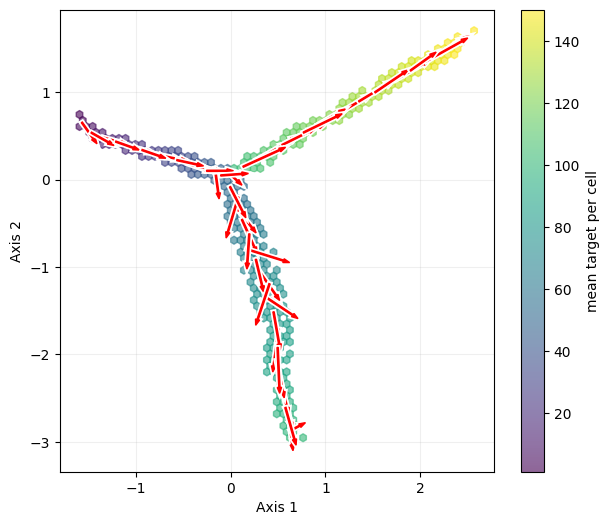

In [ ]:
# -------------------------------
# B) Learn φ on TRAIN ONLY (OT objective)
# -------------------------------

X_train = cells.astype(np.float32)
bin_ids_train = time.astype(int)
edges = edgemap

#drop some random cells to simulate missing data (only for training)
np.random.seed(42)
drop_mask = np.random.rand(len(X_train)) < 0.4
X_train = X_train[~drop_mask]
bin_ids_train = bin_ids_train[~drop_mask]

print("Training data shape after drop:", X_train.shape)

D = X_train.shape[1]
phiB = GOTFlow.make_mlp(d_in=D, d_out=2, hidden=8, depth=2)

got_B = GOTFlow(
    blur=1,
    scaling=0.8,
    reach=00.0001,
    phi=phiB,
    lambda_w=0.01,
    debias=False,
)

got_B.fit(
    X_train,
    bin_ids_train,
    edges=edges,
    edge_weights=None,
    learn_phi=True,
    transition_fit=False,     # OT only
    neg_pool_mode="nce",
    n_negatives=10,
    lr=1e-4,
    weight_decay=1e-2,
    epochs=50,
    max_src_per_edge=4000,
    max_tgt_per_edge=4000,
    whiten_update_every=10,
    drift_mode="barycentric",
    aggregate="weighted_mean",
    beta=5.0,
    verbose=True,
)

Z2 = got_B.zw_
V2 = got_B.Vw_

#Projection into 2D and Plotting
Z2, V2 = got_B.project_pls(n_components=2, standardize=True)
km = KMeans(n_clusters=50, n_init="auto", random_state=0)
cid = km.fit_predict(Z2)
P, U, counts, labs = GOTFlow.cluster_average(Z2, V2, cid, min_points=10)
got_B.plot_quiver(Z2, bin_ids_train, P, U, title='Branched')

In [ ]:
test_cells, test_time, test_cellid, test_GT, test_branch = simulate_cells(
    n_cells, n_dims, time_points, branch_point, direction_trunk, direction_A, direction_B, noise
)

print("Test shape:", test_cells.shape)  # (9900, 64) - NO PADDING!
print("Zero GT vectors:", np.sum(np.linalg.norm(test_GT, axis=1) == 0))  # 0!

drift_vec_test, _, _ = per_sample_drift_from_states_branch_aware(
    got_B,
    test_cells,
    test_time,
    X_train,
    test_branch
)

# FIXED: Include ALL 5050 predictions
cossims = []
zero_gt_count = 0

for i in range(test_GT.shape[0]):
    gt_vec = test_GT[i]
    drift_vec_i = drift_vec_test[i]
    # Always compute cosine (handles zero GT gracefully)
    cos_sim = np.dot(gt_vec, drift_vec_i) / (np.linalg.norm(gt_vec) * np.linalg.norm(drift_vec_i) + 1e-12)
    cossims.append(cos_sim)
    
#remove zeros form cossims
nozerocossims = [c for c in cossims if c != 0]

print(f"Mean cosine similarity: {np.mean(nozerocossims):.4f}")
print(f"stdev cosine similarity: {np.std(nozerocossims):.4f}")

Test shape: (2000, 16)
Zero GT vectors: 20
Mean cosine similarity: 0.6908
stdev cosine similarity: 0.1480


(2000,) 2000


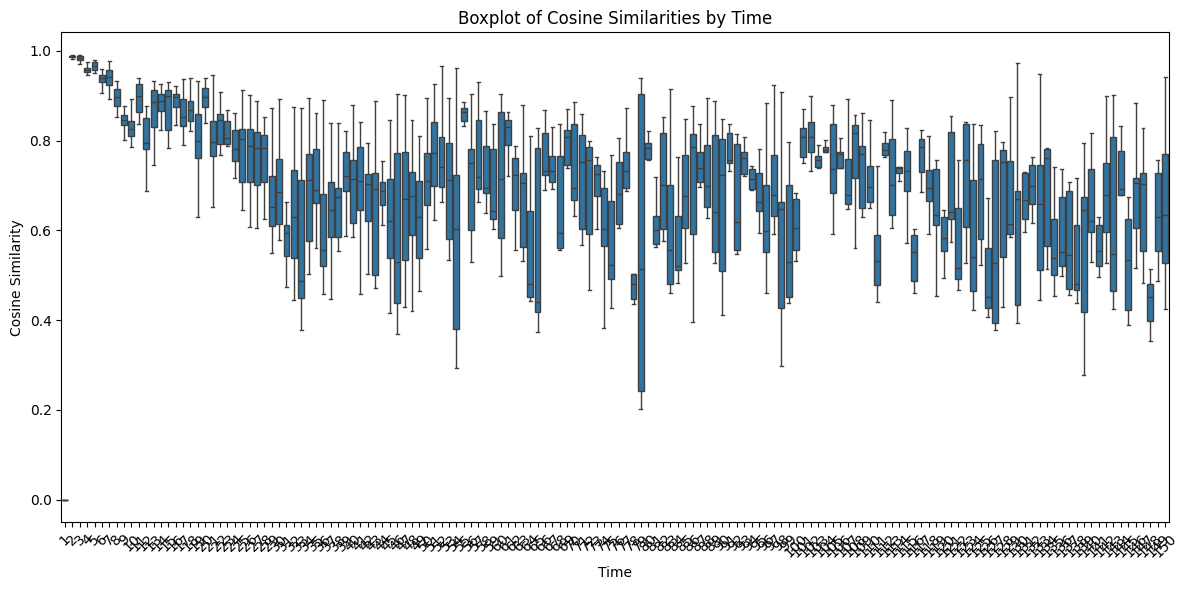

In [236]:
# Create a DataFrame for plotting
print(test_time.shape, len(cossims))

# Assuming `cossims` is a list of cosine similarities and `time` is an array of corresponding time values
data = pd.DataFrame({'Time': test_time, 'Cosine Similarity': cossims})

# Create the boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='Time', y='Cosine Similarity', data=data, showfliers=False)
plt.xlabel('Time')
plt.ylabel('Cosine Similarity')
plt.title('Boxplot of Cosine Similarities by Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

🔍 Processing 149 tree edges...
✅ 149/149 edges successful, 0 skipped


<Figure size 1500x1000 with 0 Axes>

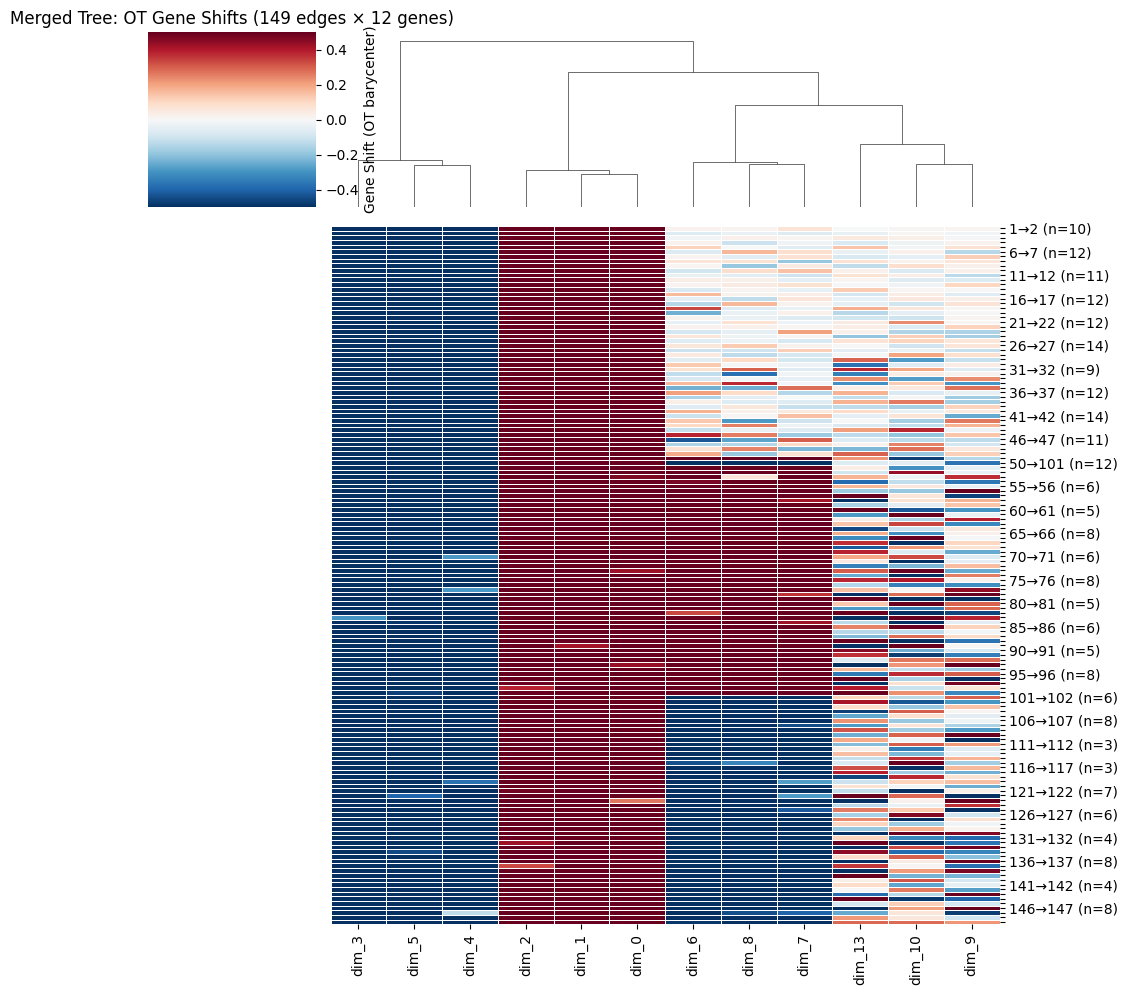

📊 Top genes: ['dim_3', 'dim_1', 'dim_5', 'dim_0', 'dim_4']...
   Signal range: [-1.837, 1.987]


In [237]:
top_n_genes = 12
train_gene_names = [f"dim_{i}" for i in range(cells.shape[1])]

heat, edge_df, top_list = edge_shift_heatmap_tree(
    got=got_B,
    X_gene=X_train,      # Your merged training data
    gene_cols=train_gene_names,
    edges=edgemap,               # Your 149 merge edges: trunk+merge+branch0+branch1
    top_genes=top_n_genes,
    signed=True,
    weight_by_mass=False,          # FIXED: Don't use noisy mass weighting
    title="Merged Tree: OT Gene Shifts",
    figsize=(15, 10), 
    save_path="branch_tree_edge_shifts.pdf",
)